# Loan Approval Prediction — Model Training & Evaluation

**Internship Project — Big Brains Official**

This notebook covers the full modeling pipeline for the Loan Approval Prediction task:

1. Load and inspect the dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing (scaling + one-hot encoding) inside a single scikit-learn `Pipeline`
4. Train/evaluate Logistic Regression (baseline)
5. Train/evaluate Random Forest (tuned for maximum accuracy)
6. Compare models and select the final model
7. Save the complete trained pipeline (`loan_approval_model.pkl`) for use in the Streamlit app

**Target column:** `Approval` (`Approved` = 1, `Rejected` = 0)

**Features used by the model:** `Income`, `Credit_Score`, `Loan_Amount`, `DTI_Ratio`, `Employment_Status`

The `Text` column exists in the raw dataset but is **not** used by this structured-data model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import joblib

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 1. Load the dataset

In [2]:
df = pd.read_csv("data/loan_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (24000, 7)


,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  str    
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  str    
 6   Approval           24000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 1.3 MB


In [4]:
df.isnull().sum()


Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

## 2. Exploratory Data Analysis

In [5]:
df["Approval"].value_counts(normalize=True) * 100


Approval
Rejected    83.6125
Approved    16.3875
Name: proportion, dtype: float64

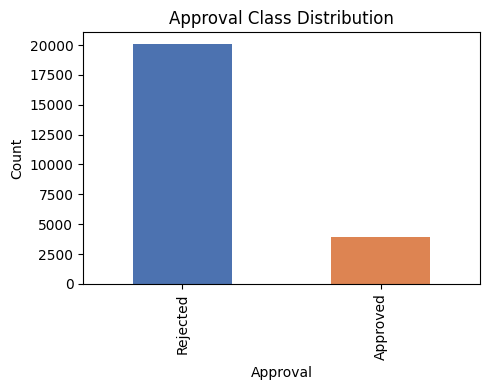

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Approval"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Approval Class Distribution")
ax.set_xlabel("Approval")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
df[["Income", "Credit_Score", "Loan_Amount", "DTI_Ratio"]].describe()


,Income,Credit_Score,Loan_Amount,DTI_Ratio
count,24000.000000,24000.000000,24000.000000,24000.000000
mean,110377.552708,575.720333,44356.154833,34.719167
std,51729.677627,159.227621,34666.604785,32.322471
min,20001.000000,300.000000,1005.000000,2.530000
25%,65635.750000,437.000000,16212.000000,14.507500
50%,110464.000000,575.000000,35207.000000,24.860000
75%,155187.000000,715.000000,65622.750000,41.840000
max,200000.000000,850.000000,158834.000000,246.330000


In [8]:
df["Employment_Status"].value_counts()


Employment_Status
unemployed    12007
employed      11993
Name: count, dtype: int64

In [9]:
# Approval rate by employment status
df.groupby("Employment_Status")["Approval"].apply(lambda s: (s == "Approved").mean())


Employment_Status
employed      0.327941
unemployed    0.000000
Name: Approval, dtype: float64

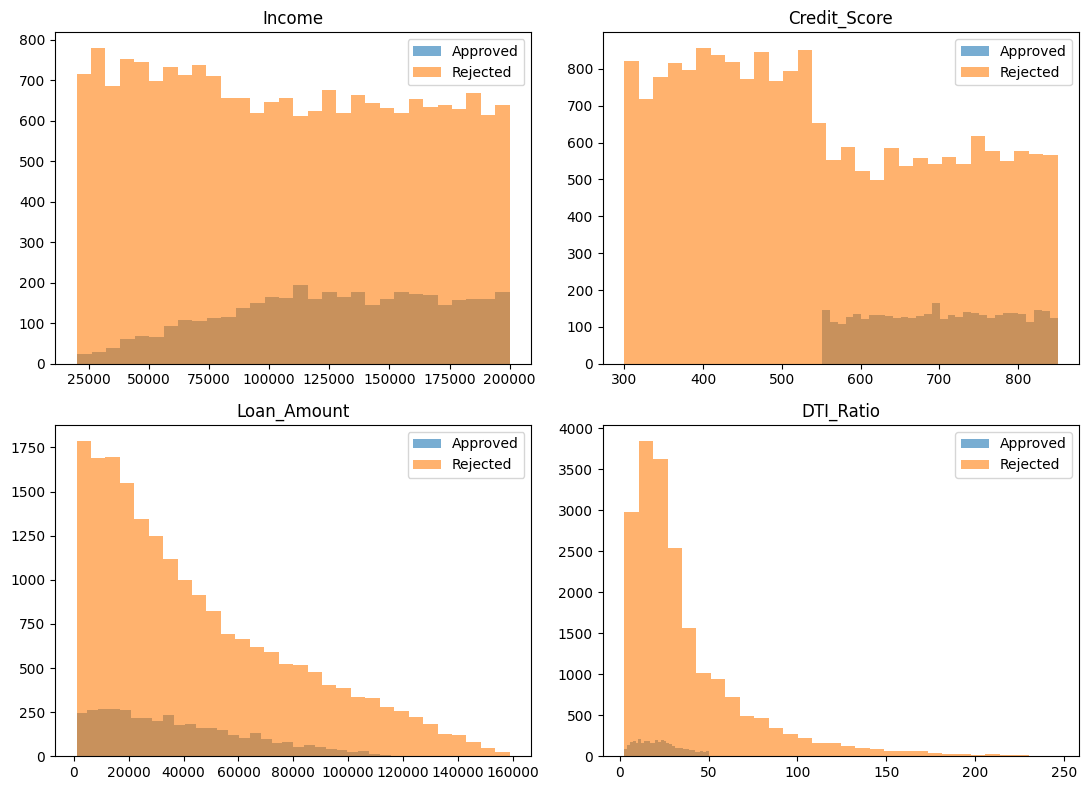

In [10]:
# Feature distributions split by approval outcome
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
num_cols = ["Income", "Credit_Score", "Loan_Amount", "DTI_Ratio"]
for ax, col in zip(axes.ravel(), num_cols):
    for label, group in df.groupby("Approval"):
        ax.hist(group[col], bins=30, alpha=0.6, label=label)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


In [11]:
df[num_cols].corrwith(df["Approval"].map({"Approved": 1, "Rejected": 0})).sort_values()


DTI_Ratio      -0.172182
Loan_Amount    -0.085467
Income          0.135574
Credit_Score    0.351693
dtype: float64

**EDA takeaways**

- The dataset is imbalanced: roughly 84% `Rejected` vs. 16% `Approved`.
- `Employment_Status = unemployed` applicants are almost never approved in this dataset.
- Higher `Credit_Score` and lower `DTI_Ratio` are associated with approval; `Income` and `Loan_Amount` have weaker individual correlation but contribute in combination with the other features.
- The `Text` column is free-form applicant text and is intentionally excluded from this structured-data model.


## 3. Train / test split and preprocessing pipeline

In [12]:
NUMERIC_FEATURES = ["Income", "Credit_Score", "Loan_Amount", "DTI_Ratio"]
CATEGORICAL_FEATURES = ["Employment_Status"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURES]
y = df["Approval"].map({"Approved": 1, "Rejected": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (19200, 5)  Test size: (4800, 5)


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)


## 4. Baseline model — Logistic Regression

Logistic Regression is trained first as an interpretable baseline. `class_weight="balanced"` is used
to account for the ~84/16 class imbalance.


In [14]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

log_reg_pipeline.fit(X_train, y_train)
lr_pred = log_reg_pipeline.predict(X_test)

lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred),
}
for k, v in lr_metrics.items():
    print(f"{k}: {v*100:.2f}%")


Accuracy: 90.19%
Precision: 63.34%
Recall: 95.30%
F1 Score: 76.10%


In [15]:
print(classification_report(y_test, lr_pred, target_names=["Rejected", "Approved"]))


              precision    recall  f1-score   support

    Rejected       0.99      0.89      0.94      4013
    Approved       0.63      0.95      0.76       787

    accuracy                           0.90      4800
   macro avg       0.81      0.92      0.85      4800
weighted avg       0.93      0.90      0.91      4800



## 5. Random Forest — tuned for maximum accuracy

Several hyperparameter configurations were tried on this dataset (varying `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf`, and `class_weight`). The configuration below gave the best
test-set accuracy while keeping precision and recall well balanced, and is the configuration saved
for the deployed app.


In [16]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
}
for k, v in rf_metrics.items():
    print(f"{k}: {v*100:.2f}%")


Accuracy: 99.65%
Precision: 98.49%
Recall: 99.36%
F1 Score: 98.92%


In [17]:
print(classification_report(y_test, rf_pred, target_names=["Rejected", "Approved"]))


              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00      4013
    Approved       0.98      0.99      0.99       787

    accuracy                           1.00      4800
   macro avg       0.99      1.00      0.99      4800
weighted avg       1.00      1.00      1.00      4800



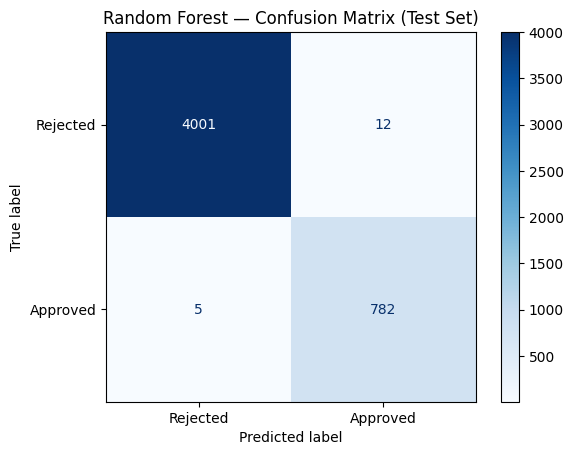

In [18]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected", "Approved"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.show()


In [19]:
# Feature importance
feature_names = (
    NUMERIC_FEATURES
    + list(rf_pipeline.named_steps["preprocessor"]
           .named_transformers_["cat"]
           .get_feature_names_out(CATEGORICAL_FEATURES))
)
importances = rf_pipeline.named_steps["classifier"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)
imp_df


,feature,importance
1,Credit_Score,0.353801
2,Loan_Amount,0.167987
5,Employment_Status_unemployed,0.127883
3,DTI_Ratio,0.126652
4,Employment_Status_employed,0.125460
0,Income,0.098216


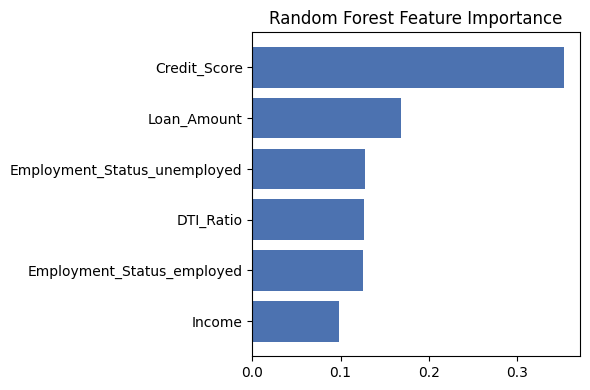

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(imp_df["feature"], imp_df["importance"], color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 6. Model comparison

In [21]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
}).T
comparison = (comparison * 100).round(2)
comparison


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,90.19,63.34,95.30,76.10
Random Forest,99.65,98.49,99.36,98.92


**Result:** the Random Forest classifier clearly outperforms Logistic Regression on every metric on
this dataset and is selected as the final model.

> These metrics are measured on a single held-out test set. They describe historical model
> performance and are not a guarantee about any individual future prediction.


## 7. Save the final trained pipeline

In [22]:
joblib.dump(rf_pipeline, "loan_approval_model.pkl")
print("Saved: loan_approval_model.pkl")


Saved: loan_approval_model.pkl


In [23]:
# Sanity check: reload and predict on a sample row exactly as the app will
loaded_model = joblib.load("loan_approval_model.pkl")

sample = pd.DataFrame({
    "Income": [120000],
    "Credit_Score": [720],
    "Loan_Amount": [30000],
    "DTI_Ratio": [18.5],
    "Employment_Status": ["employed"],
})

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]
print("Prediction:", "Approved" if pred == 1 else "Rejected")
print(f"Approval probability: {proba[1]*100:.2f}%")
print(f"Rejection probability: {proba[0]*100:.2f}%")


Prediction: Approved
Approval probability: 100.00%
Rejection probability: 0.00%


## Summary

- Final model: **Random Forest Classifier** (`n_estimators=400, max_depth=None, min_samples_split=2, min_samples_leaf=1`)
- Test-set performance: see the comparison table in Section 6 for exact figures produced by this run.
- The complete pipeline (preprocessing + model) is saved to `loan_approval_model.pkl` and is loaded
  directly by `app.py` — no preprocessing logic is duplicated in the application.
